# 📊 W09 — Scenario Generation & Cost-Benefit Analysis

**Objective**: Demonstrate the decision support pipeline on a single unit.

**Pipeline**: RUL prediction → BI context → Scenario generation → Cost-benefit → Recommendation

**Author**: Fatima Khadija Benzine — March 2026

---
## 0. Setup

In [1]:
import os
if not os.path.exists('/content/PhD-Project-'):
    !git clone https://github.com/f-khadija-benzine/PhD-Project-.git /content/PhD-Project-
!pip install xgboost -q
os.chdir('/content/PhD-Project-/src')

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json

project_root = Path('/content/PhD-Project-')
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = f'/content/drive/MyDrive/PhD_results/W09_{TIMESTAMP}'
os.makedirs(SAVE_DIR, exist_ok=True)

from data_loader import MultiDatasetLoader
from preprocessing import DataNormalizer, create_sliding_windows, evaluate_per_unit
from bi_fusion import BIFusionPipeline, CONTINUOUS_BI_VARS
from feature_selection import BIAwareFeatureSelector
from ml_branch import MLBranch
from scenario_generator import (
    UnitContext, ScenarioGenerator, cost_benefit_table,
    generate_recommendation, plot_scenario_comparison,
    plot_degradation_trajectories,
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"Save: {SAVE_DIR}")
print("All imports ✓")

Cloning into '/content/PhD-Project-'...
remote: Enumerating objects: 310, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 310 (delta 8), reused 6 (delta 6), pack-reused 290 (from 1)
Receiving objects: 100% (310/310), 6.19 MiB | 13.02 MiB/s, done.
Resolving deltas: 100% (146/146), done.
Mounted at /content/drive
Save: /content/drive/MyDrive/PhD_results/W09_20260319_0211
All imports ✓


---
## 1. Load Data + Best ML Model

In [2]:
DATASET = 'FD001'
W = 30
PAD = False

loader = MultiDatasetLoader()
ds = loader.load_cmapss_dataset(DATASET)
meta_cols = ['unit', 'cycle', 'rul']
train_raw = ds['train'].copy()
test_raw = ds['test'].copy()
train_raw['rul'] = train_raw['rul'].clip(upper=125)
if 'rul' in test_raw.columns:
    test_raw['rul'] = test_raw['rul'].clip(upper=125)

sensor_cols = [c for c in train_raw.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_raw.columns if c.startswith('setting_')]

norm = DataNormalizer(method='minmax')
train_norm = norm.fit_transform(train_raw, sensor_cols + setting_cols)
test_norm = norm.transform(test_raw)

fusion = BIFusionPipeline()
train_fused = fusion.fuse(train_norm, DATASET, split='train', encode_categoricals=True)
test_fused = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)
bi_cols = fusion.get_bi_columns(train_fused)
bi_cont = [c for c in CONTINUOUS_BI_VARS if c in train_fused.columns]
bi_norm = DataNormalizer(method='minmax')
train_fused = bi_norm.fit_transform(train_fused, bi_cont)
test_fused = bi_norm.transform(test_fused)

sel_corr = BIAwareFeatureSelector(variance_threshold=0.01, correlation_threshold=0.95)
fn_corr = sel_corr.select_features(data=train_fused, sensor_cols=sensor_cols,
    bi_cols=bi_cols, setting_cols=setting_cols, exclude_cols=meta_cols)
tr_corr = sel_corr.transform(train_fused, keep_cols=meta_cols)
te_corr = sel_corr.transform(test_fused, keep_cols=meta_cols)
X_train, y_train = create_sliding_windows(tr_corr, W, fn_corr, 'rul', pad=PAD)
X_test, y_test = create_sliding_windows(te_corr, W, fn_corr, 'rul', pad=PAD)

print(f"Data ready: {X_train.shape} train, {X_test.shape} test")

Loading FD001 dataset...
  Files: train=True, test=True, rul=True
  - Training data shape: (20631, 26)
  - Training units: 100
  - Training RUL range: [0, 361]
  - Test data shape: (13096, 26)
  - RUL values shape: (100, 1)
  - Test units found: 100 (units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]...)
  - RUL values provided: 100
    Unit 1: max_cycle=31, base_RUL=112
    Unit 2: max_cycle=49, base_RUL=98
    Unit 3: max_cycle=126, base_RUL=69
✓ FD001 loaded: 20631 train, 13096 test samples

=== BI Fusion: FD001 (train) ===
  Sensor data: (20631, 27)
  BI data loaded: 20631 rows, 100 units
  Fused data: (20631, 44)
  Features: 21 sensor + 17 BI

=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI

=== BI-Aware Feature Selection ===
  Input: 21 sensor + 17 BI + 3 setting = 41 total
  Variance filter (sensor/settings only):
    Removed 9: ['sensor_1', 'sensor_5'

In [4]:
# Load best ML params (correlation) and DL params (AFICv)
RESULTS_W05 = '/content/drive/MyDrive/PhD_results/W05_20260303_0304'

with open(f'{RESULTS_W05}/A2_ml_grid_best_20260303_0304.json', 'r') as f:
    ml_saved = json.load(f)
with open(f'{RESULTS_W05}/B2_dl_grid_best_20260303_0304.json', 'r') as f:
    dl_saved = json.load(f)

best_ml = ml_saved['params']
best_dl = dl_saved['params']
alpha = (1/dl_saved['cv_rmse']) / (1/ml_saved['cv_rmse'] + 1/dl_saved['cv_rmse'])

print(f"ML: {best_ml['feature_selection']} — CV RMSE: {ml_saved['cv_rmse']:.2f}")
print(f"DL: {best_dl['feature_selection']} — CV RMSE: {dl_saved['cv_rmse']:.2f}")
print(f"Fusion α = {alpha:.3f} (DL), 1-α = {1-alpha:.3f} (ML)")# Load best ML params and train
RESULTS_W05 = '/content/drive/MyDrive/PhD_results/W05_20260303_0304'
with open(f'{RESULTS_W05}/A2_ml_grid_best_20260303_0304.json', 'r') as f:
    ml_saved = json.load(f)
best_ml = ml_saved['params']
print(f"ML params: {best_ml}")

ml_model = MLBranch(model_type='xgboost',
    flatten_strategy=best_ml['flatten_strategy'],
    n_estimators=best_ml['n_estimators'],
    max_depth=best_ml['max_depth'],
    learning_rate=best_ml['learning_rate_xgb'])
ml_model.fit(X_train, y_train, feature_names=fn_corr)

y_pred = ml_model.predict(X_test)
print(f"ML trained ✓ — predictions ready")

ML: correlation — CV RMSE: 2.51
DL: aficv — CV RMSE: 3.76
Fusion α = 0.400 (DL), 1-α = 0.600 (ML)
ML params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.05, 'flatten_strategy': 'statistics', 'feature_selection': 'correlation'}

[ML Branch] xgboost — statistics
  Input: (17731, 30, 32) → Flattened: (17731, 192)
  Training complete ✓
ML trained ✓ — predictions ready


---
## 2. Select a Unit for Demonstration

In [5]:
# Find last prediction per unit
unit_results = []
idx = 0
for u in sorted(te_corr['unit'].unique()):
    T = len(te_corr[te_corr['unit'] == u])
    n_win = max(T - (W - 1), 0)
    if n_win > 0:
        last_pred = y_pred[idx + n_win - 1]
        last_true = y_test[idx + n_win - 1]
        last_cycle = te_corr[te_corr['unit'] == u]['cycle'].max()

        # Get BI values for this unit (last row)
        unit_row = te_corr[te_corr['unit'] == u].iloc[-1]

        unit_results.append({
            'unit': u, 'cycle': last_cycle,
            'pred_rul': last_pred, 'true_rul': last_true,
            'start_idx': idx, 'n_windows': n_win,
            'downtime_penalty': unit_row.get('downtime_penalty', 0),
            'pm_cost': unit_row.get('pm_cost', 0),
            'cm_cost': unit_row.get('cm_cost', 0),
            'revenue_per_hour': unit_row.get('revenue_per_hour', 0),
            'technician_available': unit_row.get('technician_available', 1),
            'spare_parts_available': unit_row.get('spare_parts_available', 1),
            'spare_parts_lead_time': unit_row.get('spare_parts_lead_time', 0),
            'labor_rate_standard': unit_row.get('labor_rate_standard', 0),
            'labor_rate_overtime': unit_row.get('labor_rate_overtime', 0),
            'contract_penalty_active': unit_row.get('contract_penalty_active', 0),
        })
    idx += n_win

df_units = pd.DataFrame(unit_results)
print("=== Unit Overview (sorted by predicted RUL) ===")
print(df_units[['unit', 'cycle', 'pred_rul', 'true_rul', 'downtime_penalty']]
      .sort_values('pred_rul').head(10).to_string(index=False))

print(f"\n--- Critical units (pred RUL < 20) ---")
critical = df_units[df_units['pred_rul'] < 20]
print(critical[['unit', 'cycle', 'pred_rul', 'true_rul']].to_string(index=False))

=== Unit Overview (sorted by predicted RUL) ===
 unit  cycle  pred_rul  true_rul  downtime_penalty
   76    205  5.033516      10.0          0.956056
   81    213  5.269482       8.0          0.911944
   34    203  6.262615       7.0          0.871430
   68    187  7.542913       8.0          0.870516
   31    196  8.674250       8.0          0.902775
   82    162 11.081883       9.0          0.905843
   49    303 11.783976      21.0          0.891065
   20    184 11.936246      16.0          0.892822
   35    198 14.899708      11.0          0.813675
   56    136 16.054535      15.0          0.875230

--- Critical units (pred RUL < 20) ---
 unit  cycle  pred_rul  true_rul
   20    184 11.936246      16.0
   31    196  8.674250       8.0
   34    203  6.262615       7.0
   35    198 14.899708      11.0
   42    156 16.536655      10.0
   49    303 11.783976      21.0
   56    136 16.054535      15.0
   68    187  7.542913       8.0
   76    205  5.033516      10.0
   81    213  5.26948

In [6]:
# Select a critical unit for detailed analysis
# Pick one with low predicted RUL and high downtime_penalty (interesting case)
UNIT_ID = critical.sort_values('downtime_penalty', ascending=False).iloc[0]['unit']
unit_info = df_units[df_units['unit'] == UNIT_ID].iloc[0]

print(f"\n=== Selected Unit {int(UNIT_ID)} ===")
print(f"  Current cycle:      {int(unit_info['cycle'])}")
print(f"  Predicted RUL:      {unit_info['pred_rul']:.1f} cycles")
print(f"  True RUL:           {unit_info['true_rul']:.0f} cycles")
print(f"  Downtime penalty:   {unit_info['downtime_penalty']:.3f}")
print(f"  PM cost:            {unit_info['pm_cost']:.3f}")
print(f"  CM cost:            {unit_info['cm_cost']:.3f}")
print(f"  CM/PM ratio:        {unit_info['cm_cost']/max(unit_info['pm_cost'], 0.001):.1f}x")


=== Selected Unit 76 ===
  Current cycle:      205
  Predicted RUL:      5.0 cycles
  True RUL:           10 cycles
  Downtime penalty:   0.956
  PM cost:            0.400
  CM cost:            0.154
  CM/PM ratio:        0.4x


---
## 3. Build Unit Context from BI Data

In [19]:
# Use RAW BI values (before normalization)
test_fused_raw = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)

unit_raw = test_fused_raw[test_fused_raw['unit'] == UNIT_ID].iloc[-1]

context = UnitContext(
    unit_id=int(UNIT_ID),
    current_cycle=int(unit_info['cycle']),
    predicted_rul=float(unit_info['pred_rul']),
    pm_cost=float(unit_raw['pm_cost']),
    cm_cost=float(unit_raw['cm_cost']),
    downtime_penalty=float(unit_raw['downtime_penalty']),
    revenue_per_hour=float(unit_raw['revenue_per_hour']),
    technician_available=int(unit_raw['technician_available']),
    spare_parts_available=int(unit_raw['spare_parts_available']),
    spare_parts_lead_time=float(unit_raw['spare_parts_lead_time']),
    labor_rate_standard=float(unit_raw['labor_rate_standard']),
    labor_rate_overtime=float(unit_raw['labor_rate_overtime']),
    contract_penalty_active=int(unit_raw.get('contract_penalty_active', 0)),
)

print(f"=== Unit Context (raw BI values) ===")
print(f"  PM cost:       ${context.pm_cost:,.0f}")
print(f"  CM cost:       ${context.cm_cost:,.0f} ({context.cm_to_pm_ratio:.1f}x PM)")
print(f"  Downtime:      ${context.downtime_penalty:,.0f}/hour")
print(f"  Revenue:       ${context.revenue_per_hour:,.0f}/hour")


=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI
=== Unit Context (raw BI values) ===
  PM cost:       $495
  CM cost:       $3,528 (7.1x PM)
  Downtime:      $15,398/hour
  Revenue:       $7,593/hour


---
## 4. Generate Maintenance Scenarios

In [20]:
generator = ScenarioGenerator(
    w_cost=0.6,
    w_risk=0.4,
    pm_downtime_hours=8,
    cm_downtime_hours=48,
)

scenarios = generator.generate_scenarios(
    context,
    n_pm_times=5,
    restoration_levels=[0.5, 0.7, 0.9],
)

print(f"Generated {len(scenarios)} scenarios")
print(f"  - 1 Do Nothing (baseline)")
print(f"  - {len(scenarios)-1} PM scenarios (5 times × 3 restoration levels)")

Generated 16 scenarios
  - 1 Do Nothing (baseline)
  - 15 PM scenarios (5 times × 3 restoration levels)


---
## 5. Cost-Benefit Analysis

In [21]:
# Full comparison table
df_scenarios = cost_benefit_table(scenarios)

print(f"=== Scenario Ranking (best first) ===")
print(df_scenarios[['Scenario', 'Total Cost', 'Failure Risk', 'RUL After PM', 'Score']]
      .to_string(index=False))

=== Scenario Ranking (best first) ===
                 Scenario  Total Cost  Failure Risk  RUL After PM  Score
  PM Early (t=206, η=0.5)   124059.83         0.032          64.5 0.1123
  PM Early (t=206, η=0.7)   124059.83         0.032          88.7 0.1123
  PM Early (t=206, η=0.9)   124059.83         0.032         112.9 0.1123
  PM Early (t=206, η=0.5)   124059.83         0.032          64.5 0.1123
  PM Early (t=206, η=0.7)   124059.83         0.032          88.7 0.1123
  PM Early (t=206, η=0.9)   124059.83         0.032         112.9 0.1123
  PM Early (t=207, η=0.5)   124439.47         0.126          64.0 0.1505
  PM Early (t=207, η=0.7)   124439.47         0.126          88.4 0.1505
  PM Early (t=207, η=0.9)   124439.47         0.126         112.8 0.1505
PM Optimal (t=208, η=0.5)   124819.11         0.284          63.5 0.2140
PM Optimal (t=208, η=0.7)   124819.11         0.284          88.1 0.2140
PM Optimal (t=208, η=0.9)   124819.11         0.284         112.7 0.2140
   PM Late (t

In [22]:
# Top 5 comparison
print("\n=== Top 5 Scenarios ===")
print(df_scenarios.head().to_string(index=False))


=== Top 5 Scenarios ===
               Scenario                 Action  Intervention Cycle  Restoration (η)  Intervention Cost  Downtime Cost  Production Loss  Total Cost  Failure Risk  RUL After PM  Score
PM Early (t=206, η=0.5) preventive_maintenance                 206              0.5             494.51      123185.68           379.64   124059.83         0.032          64.5 0.1123
PM Early (t=206, η=0.7) preventive_maintenance                 206              0.7             494.51      123185.68           379.64   124059.83         0.032          88.7 0.1123
PM Early (t=206, η=0.9) preventive_maintenance                 206              0.9             494.51      123185.68           379.64   124059.83         0.032         112.9 0.1123
PM Early (t=206, η=0.5) preventive_maintenance                 206              0.5             494.51      123185.68           379.64   124059.83         0.032          64.5 0.1123
PM Early (t=206, η=0.7) preventive_maintenance                 20

In [23]:
# Cost breakdown table (for article)
top5 = df_scenarios.head(5)
print("\n=== Cost Breakdown (Top 5) ===")
print(top5[['Scenario', 'Intervention Cost', 'Downtime Cost',
            'Production Loss', 'Total Cost', 'Failure Risk', 'Score']]
      .to_string(index=False))


=== Cost Breakdown (Top 5) ===
               Scenario  Intervention Cost  Downtime Cost  Production Loss  Total Cost  Failure Risk  Score
PM Early (t=206, η=0.5)             494.51      123185.68           379.64   124059.83         0.032 0.1123
PM Early (t=206, η=0.7)             494.51      123185.68           379.64   124059.83         0.032 0.1123
PM Early (t=206, η=0.9)             494.51      123185.68           379.64   124059.83         0.032 0.1123
PM Early (t=206, η=0.5)             494.51      123185.68           379.64   124059.83         0.032 0.1123
PM Early (t=206, η=0.7)             494.51      123185.68           379.64   124059.83         0.032 0.1123


---
## 6. Recommendation

In [24]:
rec = generate_recommendation(scenarios, context)
print(rec)

RECOMMENDATION for Unit 76:
  Action: PM Early (t=206, η=0.5)
  Schedule maintenance at cycle 206
  Restoration level: 50%
  Expected cost: $124,060
  Cost savings vs. failure: $622,404 (83%)
  Risk reduction: 91.8%
  RUL after maintenance: 65 cycles
  Predicted RUL without action: 5 cycles


---
## 7. Visualizations

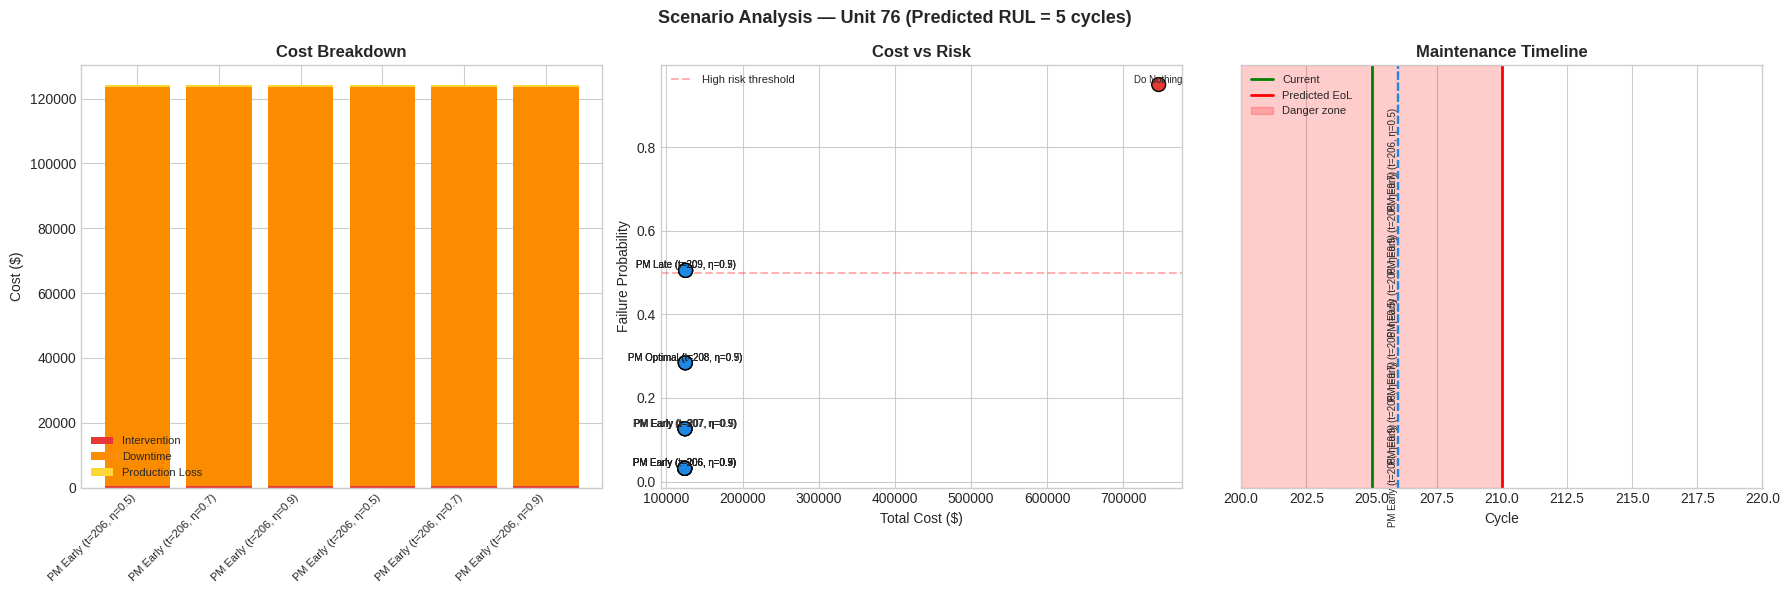

In [25]:
plot_scenario_comparison(scenarios, context,
    save_path=f'{SAVE_DIR}/fig_scenario_comparison_{TIMESTAMP}.png')
plt.close()

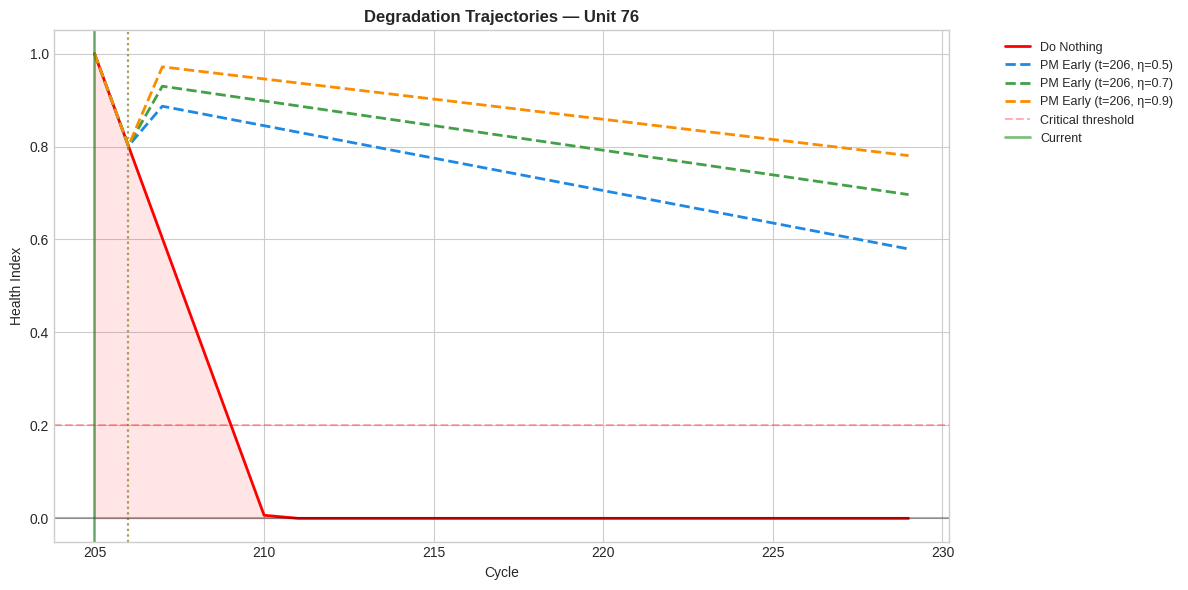

In [26]:
plot_degradation_trajectories(scenarios, context,
    save_path=f'{SAVE_DIR}/fig_degradation_trajectories_{TIMESTAMP}.png')
plt.close()

---
## 8. Save Results

In [27]:
# Save scenario table
df_scenarios.to_csv(f'{SAVE_DIR}/scenario_table_{TIMESTAMP}.csv', index=False)

# Save recommendation
with open(f'{SAVE_DIR}/recommendation_{TIMESTAMP}.txt', 'w') as f:
    f.write(rec)

# Save context
with open(f'{SAVE_DIR}/unit_context_{TIMESTAMP}.json', 'w') as f:
    json.dump({
        'unit_id': context.unit_id,
        'current_cycle': context.current_cycle,
        'predicted_rul': context.predicted_rul,
        'pm_cost': context.pm_cost,
        'cm_cost': context.cm_cost,
        'downtime_penalty': context.downtime_penalty,
        'best_scenario': scenarios[0].name,
        'best_score': scenarios[0].score,
        'savings_vs_failure': scenarios[-1].total_cost - scenarios[0].total_cost
            if scenarios[-1].action == 'do_nothing'
            else scenarios[0].total_cost,
    }, f, indent=2)

print(f"\n✓ All saved to {SAVE_DIR}")


✓ All saved to /content/drive/MyDrive/PhD_results/W09_20260319_0211


---
## Files saved:
```
PhD_results/W09_YYYYMMDD_HHMM/
    scenario_table_*.csv
    recommendation_*.txt
    unit_context_*.json
    fig_scenario_comparison_*.png
    fig_degradation_trajectories_*.png
```

In [15]:
# Check raw BI values for this unit
unit_bi = te_corr[te_corr['unit'] == UNIT_ID].iloc[-1]
for col in ['pm_cost', 'cm_cost', 'downtime_penalty', 'revenue_per_hour']:
    if col in unit_bi.index:
        print(f"  {col}: {unit_bi[col]:.4f}")

  pm_cost: 0.4005
  cm_cost: 0.1537
  downtime_penalty: 0.9561
  revenue_per_hour: 0.3659


In [16]:
!grep -n -A 3 "pm_cost\|cm_cost\|downtime_penalty\|revenue_per_hour" /content/PhD-Project-/src/bi_fusion.py | head -40


37:    'pm_cost':              {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
38:    'cm_cost':              {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
39-    'labor_rate_standard':  {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
40-    'labor_rate_overtime':  {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
41-    # MES production — per shift (~10 flights)
--
43:    'downtime_penalty':     {'delta': 10, 'source': 'MES', 'type': 'continuous'},
44-    'maintenance_window':   {'delta': 10, 'source': 'MES', 'type': 'binary'},
45-    'shift_pattern':        {'delta': 10, 'source': 'MES', 'type': 'categorical'},
46-    # Inventory / HR — daily-weekly (~25 flights)
47:    'revenue_per_hour':     {'delta': 25, 'source': 'ERP/Finance', 'type': 'continuous'},
48-    'spare_parts_available':{'delta': 25, 'source': 'ERP/Inventory', 'type': 'binary'},
49-    'spare_parts_lead_time':{'delta': 25, 'source': 'ERP/Inventory', 'type': 'continuous'},
50-    'technician_avai

In [17]:
!grep -n "def generate\|def fuse\|np.random\|pm_cost\|cm_cost" /content/PhD-Project-/src/bi_fusion.py | head -30

37:    'pm_cost':              {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
38:    'cm_cost':              {'delta': 50, 'source': 'ERP', 'type': 'continuous'},
146:    def fuse(self,


In [18]:
# Recharge sans normalisation BI
test_fused_raw = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)
unit_raw = test_fused_raw[test_fused_raw['unit'] == UNIT_ID].iloc[-1]
for col in ['pm_cost', 'cm_cost', 'downtime_penalty', 'revenue_per_hour']:
    if col in unit_raw.index:
        print(f"  {col}: {unit_raw[col]:.4f}")


=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI
  pm_cost: 494.5100
  cm_cost: 3527.8800
  downtime_penalty: 15398.2100
  revenue_per_hour: 7592.7900


In [28]:
# Export FD001 test with raw BI data to CSV
test_fused_raw = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)

# Save to Drive
output_path = f'{SAVE_DIR}/FD001_test_with_BI.csv'
test_fused_raw.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {test_fused_raw.shape}")
print(f"Columns: {list(test_fused_raw.columns)}")

# Same for train
train_fused_raw = fusion.fuse(train_norm, DATASET, split='train', encode_categoricals=True)
output_path_train = f'{SAVE_DIR}/FD001_train_with_BI.csv'
train_fused_raw.to_csv(output_path_train, index=False)
print(f"\nSaved: {output_path_train}")
print(f"Shape: {train_fused_raw.shape}")


=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI
Saved: /content/drive/MyDrive/PhD_results/W09_20260319_0211/FD001_test_with_BI.csv
Shape: (13096, 44)
Columns: ['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'rul', 'pm_cost', 'cm_cost', 'labor_rate_standard', 'labor_rate_overtime', 'downtime_penalty', 'revenue_per_hour', 'spare_parts_available', 'spare_parts_lead_time', 'technician_available', 'maintenance_window', 'contract_penalty_active', 'production_priority_0', 'production_priority_1', 'production_priority_2', 'shift_pattern_0', 'shift_pattern_1', 'shift_pattern_2']

=== BI Fusion: FD001 (train) ===
  Sensor